# MSM analysis: metastable states characterization, populations, probability fluxes

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from deeptime.plots import Network
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

from matplotlib.patches import Patch
from matplotlib import color_sequences
color_sequence = color_sequences['Paired']

In [2]:
n_macro = 12
timelag_macro = 1000 # validated with the CK test, see notebook step_3_msm_construction.ipynb

macro_traj = np.load(f"intermediate_outputs/traj_pcca_{n_macro}_assignments.npy")
pca_traj = np.load("intermediate_outputs/mindists2_pca_5.npz")['arr_0']

#### Build macrostate MSM

In [3]:
estimator_counts = TransitionCountEstimator(
    lagtime=int(timelag_macro),
    count_mode="sliding-effective"
)
macro_counts = estimator_counts.fit(macro_traj).fetch_model()

estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
macro_msm = estimator_transition.fit(macro_counts).fetch_model()


In [22]:
def plot_msm_network(
    T,
    ax=None,
    state_colors=None,
    pi=None,
    labels=None,
    top_k_per_state=2,
    min_prob=0.02,
    node_size_range=(800, 3500),
    edge_width_range=(1.0, 6.0),
    self_edges=False,
    seed=0,
):
    T = np.asarray(T, dtype=float)
    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    if state_colors is None:
        state_colors = ["lightgrey"] * n

    if pi is None:
        # left stationary distribution for row-stochastic T
        w, v = np.linalg.eig(T.T)
        idx = np.argmin(np.abs(w - 1))
        pi = np.real(v[:, idx])
        pi = np.abs(pi)
        pi = pi / pi.sum()

    # -----------------------------
    # Full graph for layout
    # -----------------------------
    G_full = nx.from_numpy_array(T, create_using=nx.DiGraph())

    pos = nx.spring_layout(
        G_full,
        weight="weight",
        k=5,
        seed=seed
    )

    # -----------------------------
    # Filter edges for plotting
    # -----------------------------
    G_plot = nx.DiGraph()
    G_plot.add_nodes_from(range(n))

    for i in range(n):
        probs = T[i].copy()

        if not self_edges:
            probs[i] = 0.0

        candidates = np.where(probs >= min_prob)[0]

        if len(candidates) > 0:
            strongest = candidates[np.argsort(probs[candidates])[-top_k_per_state:]]

            for j in strongest:
                G_plot.add_edge(i, j, weight=T[i, j])

    # -----------------------------
    # Node sizes
    # -----------------------------
    smin, smax = node_size_range
    if np.max(pi) > np.min(pi):
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Edge widths
    # -----------------------------
    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=state_colors,
        edgecolors="black",
        linewidths=1.5,
        alpha = 0.6
    )

    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        ax=ax,
        font_size=11,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        arrows=True,
        arrowsize=15,
        arrowstyle="-|>",
        min_target_margin=25,
        min_source_margin=20,
        connectionstyle="arc3,rad=0.15",
        alpha=0.75
    )

    ax.set_title("Dominant macrostate transitions")
    ax.axis("off")

    return ax, G_plot, pos

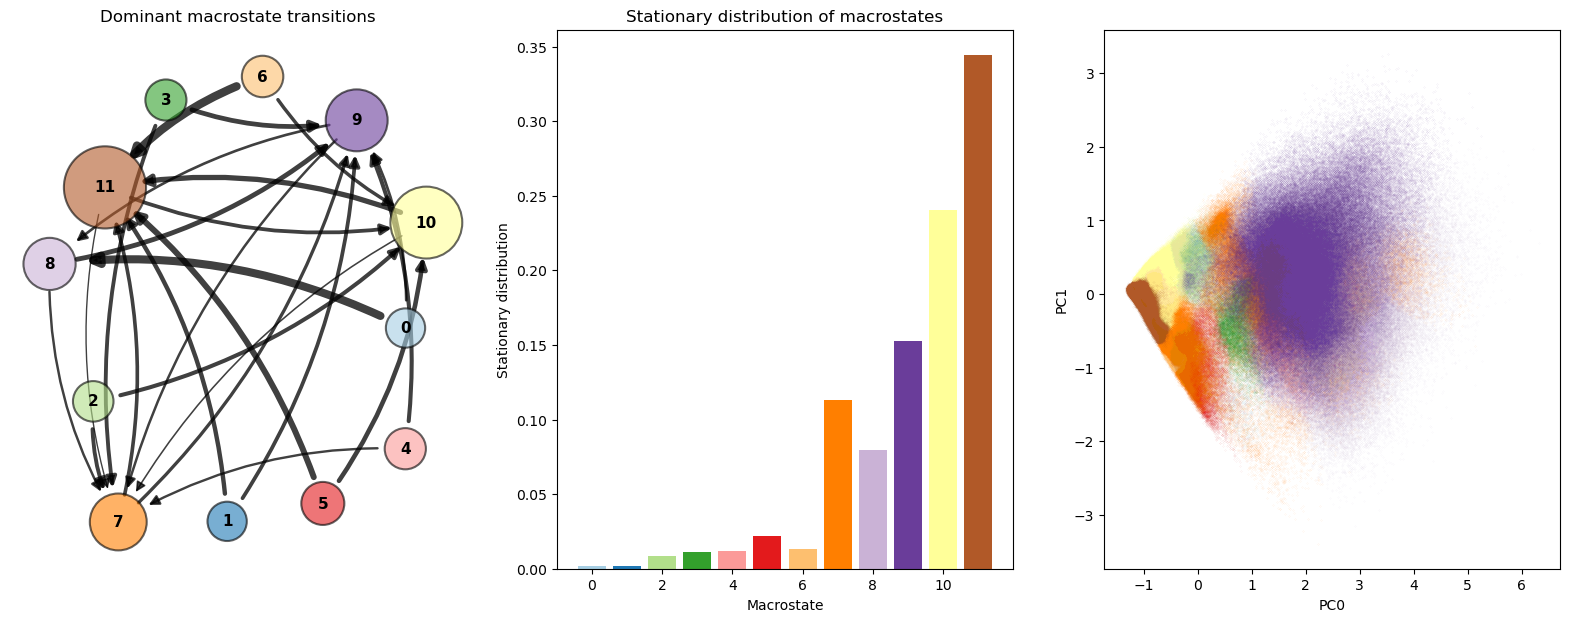

In [23]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 7))

#############################
# graph transition matrix

ax = axs[0]
ax, G_plot, pos = plot_msm_network(
    macro_msm.transition_matrix,
    ax=ax,
    state_colors=color_sequence[:n_macro],
    top_k_per_state=2,
    min_prob=0.03,
    self_edges=False,
    seed=0
)


#############################
# histogram of stationary distribution
axs[1].bar(
    np.arange(n_macro),
    macro_msm.stationary_distribution,
    color=color_sequence[:n_macro]
)
axs[1].set_xlabel("Macrostate")
axs[1].set_ylabel("Stationary distribution")
axs[1].set_title("Stationary distribution of macrostates")

#############################
# pca plot
ax = axs[2]
for id in range(n_macro):
    frames = pca_traj[macro_traj == id]
    ax.scatter(
        frames[:, 0],
        frames[:, 1],
        color=color_sequence[id],
        alpha = 0.3,
        s=0.01,
    )
ax.set_xlabel(f"PC0")
ax.set_ylabel(f"PC1")

plt.show()